# DESeq2 por tratamiento — transiciones de dormancia

Para cada transición (EcoD vs EndoD, EndoR vs EndoD, EcoD vs EndoR) se ejecuta DESeq2
3 veces (Control, Ascórbico, Etileno) usando solo las muestras de ese tratamiento.

Output: 3 CSV con LFC y padj por tratamiento para cada gen.

## 1. Configuración

In [ ]:
EXPRESSION_FILE = './Expression_Profile.Nonpareil.gene.xlsx'  # <-- ajusta ruta
METADATA_FILE   = './metadatos.xlsx'  # <-- ajusta ruta
OUTPUT_DIR      = './treatment_DEG_results'

PADJ_THRESHOLD = 0.05
LFC_THRESHOLD  = 1.0
MIN_COUNTS     = 10
MIN_SAMPLES    = 3

EXCLUDE_SAMPLES = [10]  # S10: outlier RNA-seq (5.9M reads, 59% mapeo)

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('OK')

OK


## 2. Librerías

In [6]:
import pandas as pd
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import warnings, time
warnings.filterwarnings('ignore')
print('OK')

OK


In [5]:
# Si pydeseq2 no está instalado: pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
print('pydeseq2 importado OK')

  Using cached pydeseq2-0.5.4-py3-none-any.whl.metadata (9.3 kB)
  Using cached anndata-0.12.10-py3-none-any.whl.metadata (9.9 kB)
  Using cached formulaic_contrasts-1.0.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached formulaic-1.2.1-py3-none-any.whl.metadata (7.0 kB)
  Using cached array_api_compat-1.14.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached legacy_api_wrap-1.5-py3-none-any.whl.metadata (2.2 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached zarr-3.1.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached interface_meta-1.3.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached narwhals-2.19.0-py3-none-any.whl.metadata (14 kB)
  Using cached session_info-1.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached donfig-0.8.1.post1-py3-none-any.whl.metadata (5.0 kB)
  Using cached stdlib_list-0.12.0-py3-none-any.whl.metadata (3.3 kB)
Using cached pydeseq2-0.5.4-py3-none-any.whl (45 kB)
Using cached anndata-0.12.10-py3-none-any.whl (176 kB)
Using ca

## 3. Cargar datos

In [9]:
print('Cargando...')
expr = pd.read_excel(EXPRESSION_FILE)
expr = expr.set_index('Gene_ID')

# Counts — filas=muestras, columnas=genes
counts = expr[[f'{i}_Read_Count' for i in range(1, 40)]].astype(int).T
counts.index = [str(i) for i in range(1, 40)]

# Excluir muestra outlier
counts = counts.drop([str(s) for s in EXCLUDE_SAMPLES], errors='ignore')

# Descripción
desc = expr['Description'].to_dict()

# Filtro mínimo
counts_filt = counts.loc[:, (counts >= MIN_COUNTS).sum() >= MIN_SAMPLES]
print(f'Genes tras filtro: {counts_filt.shape[1]:,}')

# ── Metadatos desde Excel ────────────────────────────────────────────────────
# Se cargan directamente del archivo de metadatos para evitar
# asignaciones incorrectas por orden de muestra.
meta_raw = pd.read_excel(METADATA_FILE)
meta_raw = meta_raw.dropna(subset=['ID'])
meta_raw['ID'] = meta_raw['ID'].astype(int)
meta_raw = meta_raw.drop_duplicates(subset='ID')
meta_raw = meta_raw[meta_raw['ID'] <= 39].copy()

# Normalizar nombres de estado y tratamiento
state_map = {
    'Endodormancy':          'Endodormancy',
    'Endodormancy release':  'EndoRelease',
    'EndoRelease':           'EndoRelease',
    'Ecodormancy':           'Ecodormancy',
}
treat_map = {
    'Control':   'Control',
    'Asc':       'Ascorbic',
    'Ascorbic':  'Ascorbic',
    'Eth':       'Ethylene',
    'Ethylene':  'Ethylene',
    'Ethephon':  'Ethylene',
}

meta_raw['state']     = meta_raw['Dormancy state'].str.strip().map(state_map)
meta_raw['treatment'] = meta_raw['Treatment'].fillna('Control').astype(str).str.strip().map(treat_map)

# Excluir muestras outlier y alinear con counts
meta_raw = meta_raw[~meta_raw['ID'].isin(EXCLUDE_SAMPLES)]
meta = meta_raw.set_index(meta_raw['ID'].astype(str))[['state', 'treatment']]
meta = meta.loc[meta.index.isin(counts_filt.index)]
counts_filt = counts_filt.loc[meta.index]

# Verificar
print(f'Muestras: {len(meta)}')
print(pd.crosstab(meta['state'], meta['treatment']))

# Comprobar que no hay NaN en state/treatment
assert meta['state'].isna().sum() == 0, 'ERROR: hay muestras sin estado de dormancia'
assert meta['treatment'].isna().sum() == 0, 'ERROR: hay muestras sin tratamiento'
print('Metadatos OK')

Cargando...
Genes: 22,166
treatment     Ascorbic  Control  Ethylene
state                                    
Ecodormancy          3        6         3
EndoRelease          3        3         3
Endodormancy         3        9         6


## 4. Función DESeq2
Compara dos estados usando solo las muestras de un tratamiento.

In [10]:
def run_deseq2_transition(state_A, state_B, treatment, counts_filt, meta,
                          padj_thr=0.05, lfc_thr=1.0):
    """
    Compara state_A vs state_B usando solo muestras del tratamiento indicado.
    Referencia: state_B (control de la comparación).
    LFC positivo = más expresado en state_A.
    """
    ids = meta[(meta['state'].isin([state_A, state_B])) &
               (meta['treatment'] == treatment)].index.tolist()

    if len(ids) < 4:
        print(f'    Pocas muestras ({len(ids)}) — omitido')
        return None

    meta_sub   = meta.loc[ids, ['state']].astype(str)
    counts_sub = counts_filt.loc[ids]
    n_A = (meta_sub['state'] == state_A).sum()
    n_B = (meta_sub['state'] == state_B).sum()
    print(f'    {state_A}(n={n_A}) vs {state_B}(n={n_B})', flush=True)

    t0 = time.time()
    dds = DeseqDataSet(
        counts=counts_sub, metadata=meta_sub,
        design_factors='state',
        ref_level=['state', state_B],
        quiet=True
    )
    dds.deseq2()
    stat = DeseqStats(dds, contrast=['state', state_A, state_B], quiet=True)
    stat.summary()
    res = stat.results_df.copy()
    res['regulation'] = 'NS'
    res.loc[(res['padj'] < padj_thr) & (res['log2FoldChange'] >=  lfc_thr), 'regulation'] = 'UP'
    res.loc[(res['padj'] < padj_thr) & (res['log2FoldChange'] <= -lfc_thr), 'regulation'] = 'DOWN'

    sig = res[res['regulation'].isin(['UP','DOWN'])]
    print(f'    DEGs={len(sig)} (UP={(sig["log2FoldChange"]>0).sum()}, DOWN={(sig["log2FoldChange"]<0).sum()}) | {time.time()-t0:.0f}s')
    return res

print('Función definida OK')

Función definida OK


## 5. Ejecutar análisis
**Tarda ~15-20 minutos**

In [11]:
# 3 transiciones × 3 tratamientos = 9 análisis DESeq2
TRANSITIONS = [
    ('Ecodormancy',  'Endodormancy', 'Eco_vs_Endo'),
    ('EndoRelease',  'Endodormancy', 'ER_vs_Endo'),
    ('Ecodormancy',  'EndoRelease',  'Eco_vs_ER'),
]
TREATMENTS = ['Control', 'Ascorbic', 'Ethylene']

t0_total = time.time()
all_results = {}  # {(transition_name, treatment): DataFrame}

for state_A, state_B, trans_name in TRANSITIONS:
    print(f'\n{"="*55}')
    print(f'Transición: {trans_name} ({state_A} vs {state_B})')
    print(f'{"="*55}')
    for treat in TREATMENTS:
        print(f'  Tratamiento: {treat}')
        res = run_deseq2_transition(
            state_A, state_B, treat,
            counts_filt, meta,
            padj_thr=PADJ_THRESHOLD,
            lfc_thr=LFC_THRESHOLD
        )
        all_results[(trans_name, treat)] = res

print(f'\nTiempo total: {(time.time()-t0_total)/60:.1f} min')


Transición: Eco_vs_Endo (Ecodormancy vs Endodormancy)
  Tratamiento: Control
    Ecodormancy(n=6) vs Endodormancy(n=9)
    DEGs=4758 (UP=3386, DOWN=1372) | 91s
  Tratamiento: Ascorbic
    Ecodormancy(n=3) vs Endodormancy(n=3)
    DEGs=2320 (UP=1231, DOWN=1089) | 80s
  Tratamiento: Ethylene
    Ecodormancy(n=3) vs Endodormancy(n=6)
    DEGs=1520 (UP=1001, DOWN=519) | 67s

Transición: ER_vs_Endo (EndoRelease vs Endodormancy)
  Tratamiento: Control
    EndoRelease(n=3) vs Endodormancy(n=9)
    DEGs=400 (UP=65, DOWN=335) | 84s
  Tratamiento: Ascorbic
    EndoRelease(n=3) vs Endodormancy(n=3)
    DEGs=1606 (UP=462, DOWN=1144) | 39s
  Tratamiento: Ethylene
    EndoRelease(n=3) vs Endodormancy(n=6)
    DEGs=856 (UP=562, DOWN=294) | 49s

Transición: Eco_vs_ER (Ecodormancy vs EndoRelease)
  Tratamiento: Control
    Ecodormancy(n=6) vs EndoRelease(n=3)
    DEGs=807 (UP=739, DOWN=68) | 58s
  Tratamiento: Ascorbic
    Ecodormancy(n=3) vs EndoRelease(n=3)
    DEGs=687 (UP=530, DOWN=157) | 47s
  Tr

## 6. Construir y guardar los 3 CSV finales

In [12]:
for state_A, state_B, trans_name in TRANSITIONS:
    print(f'\nConstruyendo {trans_name}...')

    # Partir del resultado Control como base
    res_ctrl = all_results.get((trans_name, 'Control'))
    if res_ctrl is None:
        print('  Sin resultado Control — omitido')
        continue

    df = res_ctrl[['baseMean','log2FoldChange','pvalue','padj','regulation']].copy()
    df.columns = ['baseMean_Control','LFC_Control','pvalue_Control',
                  'padj_Control','reg_Control']
    df['Description'] = df.index.map(desc)

    # Añadir columnas de Ascorbic y Ethylene
    for treat in ['Ascorbic', 'Ethylene']:
        res_t = all_results.get((trans_name, treat))
        if res_t is not None:
            df[f'LFC_{treat}']   = res_t['log2FoldChange']
            df[f'padj_{treat}']  = res_t['padj']
            df[f'reg_{treat}']   = res_t['regulation']
        else:
            df[f'LFC_{treat}']  = np.nan
            df[f'padj_{treat}'] = np.nan
            df[f'reg_{treat}']  = 'not_tested'

    # Reordenar columnas
    df = df[['Description',
             'baseMean_Control',
             'LFC_Control',   'padj_Control',   'reg_Control',
             'LFC_Ascorbic',  'padj_Ascorbic',  'reg_Ascorbic',
             'LFC_Ethylene',  'padj_Ethylene',  'reg_Ethylene']]

    df = df.sort_values('padj_Control')

    sig_ctrl = (df['reg_Control'].isin(['UP','DOWN'])).sum()
    sig_asc  = (df['reg_Ascorbic'].isin(['UP','DOWN'])).sum()
    sig_eth  = (df['reg_Ethylene'].isin(['UP','DOWN'])).sum()
    print(f'  DEGs Control={sig_ctrl} | Ascorbic={sig_asc} | Ethylene={sig_eth}')

    outfile = os.path.join(OUTPUT_DIR, f'DEG_{trans_name}_by_treatment.csv')
    df.to_csv(outfile)
    print(f'  Guardado: {outfile}')

print('\nFINALIZADO')


Construyendo Eco_vs_Endo...
  DEGs Control=4758 | Ascorbic=2320 | Ethylene=1520
  Guardado: ./treatment_DEG_results\DEG_Eco_vs_Endo_by_treatment.csv

Construyendo ER_vs_Endo...
  DEGs Control=400 | Ascorbic=1606 | Ethylene=856
  Guardado: ./treatment_DEG_results\DEG_ER_vs_Endo_by_treatment.csv

Construyendo Eco_vs_ER...
  DEGs Control=807 | Ascorbic=687 | Ethylene=369
  Guardado: ./treatment_DEG_results\DEG_Eco_vs_ER_by_treatment.csv

FINALIZADO


## 7. Genes candidatos — respuesta a tratamientos por transición

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CANDIDATES = {
    'PRUDU20869': 'MADS-box MADS2',
    'PRUDU31943': 'CYP79D16 (amygdalin)',
    'PRUDU30305': 'CYP71AN24 (amygdalin)',
    'PRUDU8832':  'UGT94AF3 (amygdalin)',
    'PRUDU45936': 'PR protein 1',
    'PRUDU17011': 'Lys-His transporter 2',
    'PRUDU31204': 'Purple acid phosphatase 17',
    'PRUDU26110': 'Transposón TNT 1-94',
    'PRUDU20878': 'COBRA-like protein 4',
    'PRUDU14264': 'OXA1-like protein',
    'PRUDU22466': 'GDSL esterase/lipase',
}

# Tabla resumen candidatos
rows = []
for gene, gene_desc in CANDIDATES.items():
    row = {'Gene_ID': gene, 'Description': gene_desc}
    for _, _, trans_name in TRANSITIONS:
        for treat in TREATMENTS:
            res = all_results.get((trans_name, treat))
            if res is not None and gene in res.index:
                r = res.loc[gene]
                row[f'LFC_{trans_name}_{treat}']  = round(r['log2FoldChange'], 3)
                row[f'padj_{trans_name}_{treat}'] = round(r['padj'], 4) if not pd.isna(r['padj']) else np.nan
                row[f'reg_{trans_name}_{treat}']  = r['regulation']
            else:
                row[f'LFC_{trans_name}_{treat}']  = np.nan
                row[f'padj_{trans_name}_{treat}'] = np.nan
                row[f'reg_{trans_name}_{treat}']  = 'ND'
    rows.append(row)

df_cand = pd.DataFrame(rows)
outfile = os.path.join(OUTPUT_DIR, 'candidates_treatment_by_transition.csv')
df_cand.to_csv(outfile, index=False)
print(f'Guardado: {outfile}')

# Mostrar LFC por transición y tratamiento
lfc_cols = [c for c in df_cand.columns if c.startswith('LFC_')]
print('\nLFC por transición y tratamiento:')
print(df_cand[['Gene_ID','Description'] + lfc_cols].to_string(index=False))

Guardado: ./treatment_DEG_results\candidates_treatment_by_transition.csv

LFC por transición y tratamiento:
   Gene_ID                Description  LFC_Eco_vs_Endo_Control  LFC_Eco_vs_Endo_Ascorbic  LFC_Eco_vs_Endo_Ethylene  LFC_ER_vs_Endo_Control  LFC_ER_vs_Endo_Ascorbic  LFC_ER_vs_Endo_Ethylene  LFC_Eco_vs_ER_Control  LFC_Eco_vs_ER_Ascorbic  LFC_Eco_vs_ER_Ethylene
PRUDU20869             MADS-box MADS2                    2.236                     0.918                     1.334                   0.404                    0.499                    1.340                  1.751                   0.412                  -0.005
PRUDU31943       CYP79D16 (amygdalin)                    4.944                     2.857                     3.195                   3.642                    1.009                    3.089                  1.160                   1.839                   0.108
PRUDU30305      CYP71AN24 (amygdalin)                    0.427                     1.288                    -0.1

## 8. Heatmap LFC candidatos — transición × tratamiento

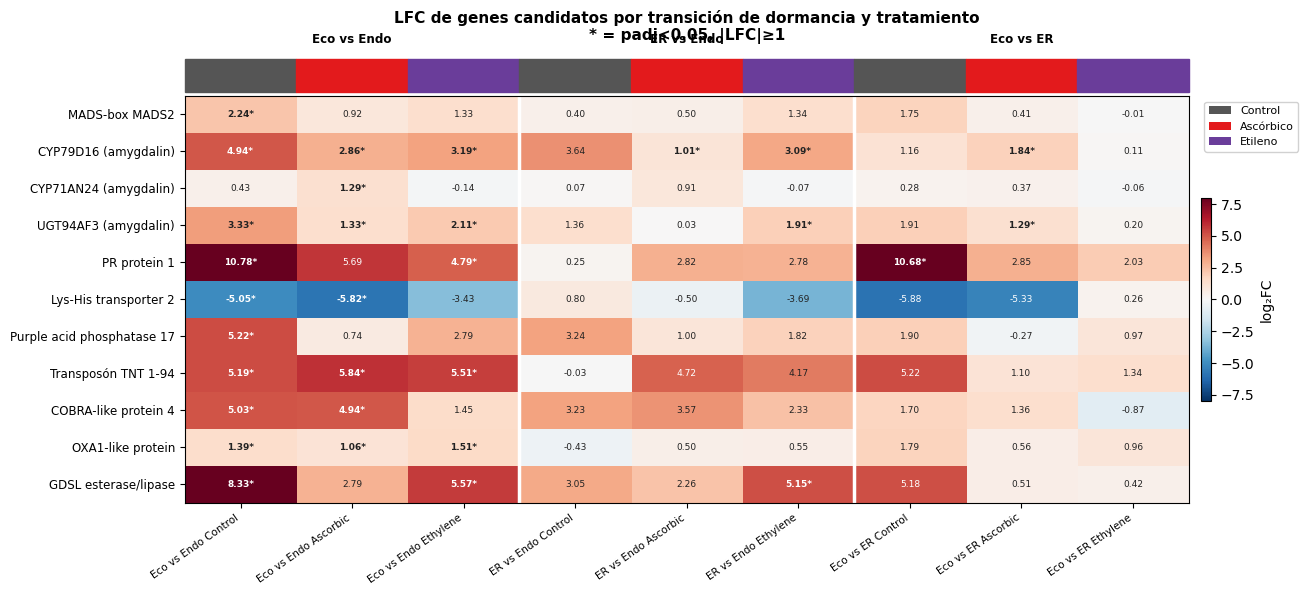

Figura guardada: ./treatment_DEG_results\treatment_heatmap_candidates_by_transition.png


In [14]:
lfc_cols = [c for c in df_cand.columns if c.startswith('LFC_')]
lfc_mat  = df_cand.set_index('Gene_ID')[lfc_cols].astype(float)

# Nombres de columnas más legibles
col_labels = []
for c in lfc_cols:
    parts = c.replace('LFC_','').split('_')
    # trans_name tiene guiones bajos también, tratar con cuidado
    col_labels.append(c.replace('LFC_','').replace('_',' '))
lfc_mat.columns = col_labels

sig_mat = df_cand.set_index('Gene_ID')[[c for c in df_cand.columns if c.startswith('reg_')]].copy()
sig_mat.columns = col_labels

gene_labels = [CANDIDATES.get(g, g) for g in lfc_mat.index]

# Agrupar columnas por transición
trans_groups = {
    'Eco vs Endo': [c for c in col_labels if 'Eco vs Endo' in c],
    'ER vs Endo':  [c for c in col_labels if 'ER vs Endo'  in c],
    'Eco vs ER':   [c for c in col_labels if 'Eco vs ER'   in c],
}

treat_colors_top = {'Control': '#555555', 'Ascorbic': '#e31a1c', 'Ethylene': '#6a3d9a'}

vmax = np.nanmax(np.abs(lfc_mat.values))
vmax = min(vmax, 8)  # cap para visualización

fig, ax = plt.subplots(figsize=(14, max(5, len(lfc_mat)*0.55)), facecolor='white')

im = ax.imshow(lfc_mat.values, aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, interpolation='nearest')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=7.5, rotation=35, ha='right')
ax.set_yticks(range(len(gene_labels)))
ax.set_yticklabels(gene_labels, fontsize=8.5)

# Anotar LFC y asteriscos
for yi in range(len(lfc_mat.index)):
    for xi in range(len(col_labels)):
        val = lfc_mat.iloc[yi, xi]
        reg = sig_mat.iloc[yi, xi]
        if not np.isnan(val):
            star = '*' if reg in ['UP','DOWN'] else ''
            color = 'white' if abs(val) > vmax*0.55 else '#222222'
            ax.text(xi, yi, f'{val:.2f}{star}',
                    ha='center', va='center', fontsize=6.5,
                    color=color,
                    fontweight='bold' if star else 'normal')

# Líneas divisorias entre transiciones
ax.axvline(2.5, color='white', linewidth=2.5)
ax.axvline(5.5, color='white', linewidth=2.5)

# Barras de tratamiento en la parte superior
for xi, col in enumerate(col_labels):
    for treat, color in treat_colors_top.items():
        if treat.lower() in col.lower():
            ax.add_patch(plt.Rectangle((xi-0.5, -1.5), 1, 0.9,
                                       color=color, clip_on=False, zorder=5))

# Etiquetas de transición
for xi_center, label in [(1, 'Eco vs Endo'), (4, 'ER vs Endo'), (7, 'Eco vs ER')]:
    ax.text(xi_center, -2.2, label, ha='center', va='top',
            fontsize=8.5, fontweight='bold', clip_on=False)

plt.colorbar(im, ax=ax, label='log₂FC', shrink=0.5, pad=0.01)
ax.set_title('LFC de genes candidatos por transición de dormancia y tratamiento\n* = padj<0.05, |LFC|≥1',
             fontsize=11, fontweight='bold', pad=40)

legend_elements = [
    mpatches.Patch(facecolor='#555555', label='Control'),
    mpatches.Patch(facecolor='#e31a1c', label='Ascórbico'),
    mpatches.Patch(facecolor='#6a3d9a', label='Etileno'),
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
outfig = os.path.join(OUTPUT_DIR, 'treatment_heatmap_candidates_by_transition.png')
plt.savefig(outfig, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figura guardada: {outfig}')